# Visualization and Inference Notebook

### Import necessary libraries  

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc
import re # for string cleaning


# Functions to open and find npz files

In [2]:
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        return archive
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None

In [3]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [4]:
EAST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_EAST_GEO_TOPO_LOMSK.nc"
EAST_f_coords = nc.Dataset(EAST_LATLONDATA)
EAST_abiLong = np.array(EAST_f_coords['Longitude'])
EAST_abiLat = np.array(EAST_f_coords['Latitude'])
EAST_abiLong[EAST_abiLong == -999] = 10
EAST_abiLat[EAST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(EAST_abiLat.shape)

(10848, 10848)


In [5]:
WEST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_WEST_GEO_TOPO_LOMSK.nc"
WEST_f_coords = nc.Dataset(WEST_LATLONDATA)
WEST_abiLong = np.array(WEST_f_coords['Longitude'])
WEST_abiLat = np.array(WEST_f_coords['Latitude'])
WEST_abiLong[WEST_abiLong == -999] = 10
WEST_abiLat[WEST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(WEST_abiLat.shape)


(10848, 10848)


In [6]:
def visualize_chip(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude, file_name):
    plt.figure(figsize=(10, 8))

    # Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]

    # Draw the ABI image
    plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    # we decidede to use pcolormesh due to the distortion of the chip

    # Draw the transect on top
    # data['Longitude'] and data['Latitude'] are the transect 
    plt.plot(cloudsat_longitude, cloudsat_latitude, color='red', linewidth=2, label='CloudSat Track')
    
    plt.title(f"ABI Chip with CloudSat Transect Overlay\n{file_name}")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    plt.show()

In [14]:
output_directory = '/explore/nobackup/projects/pix4dcloud/scratch/abi-cloudsat-crop-test-inner-disk-2400/'

files = find_npz_files(output_directory)

westCount = 0
eastCount = 0

for file in files:
    if 'west' in file:
        westCount+=1
    if 'east' in file:
        eastCount+=1

print('west', westCount)
print('east', eastCount)

# print(files)
print('total', len(files))

start = 10

files = files[start:start+3] # only take 3 so it doesn't overload

west 0
east 123
total 123


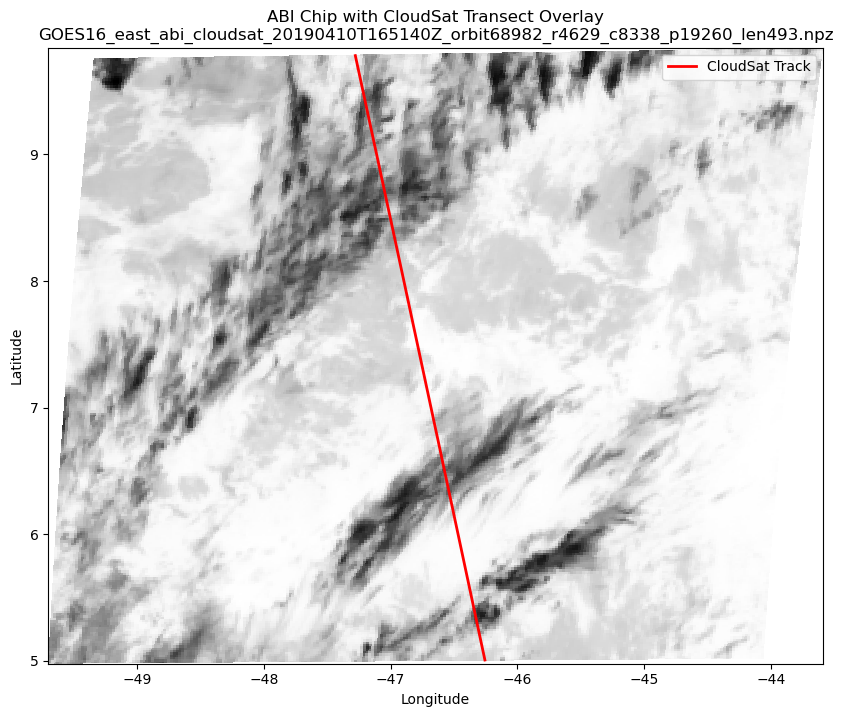

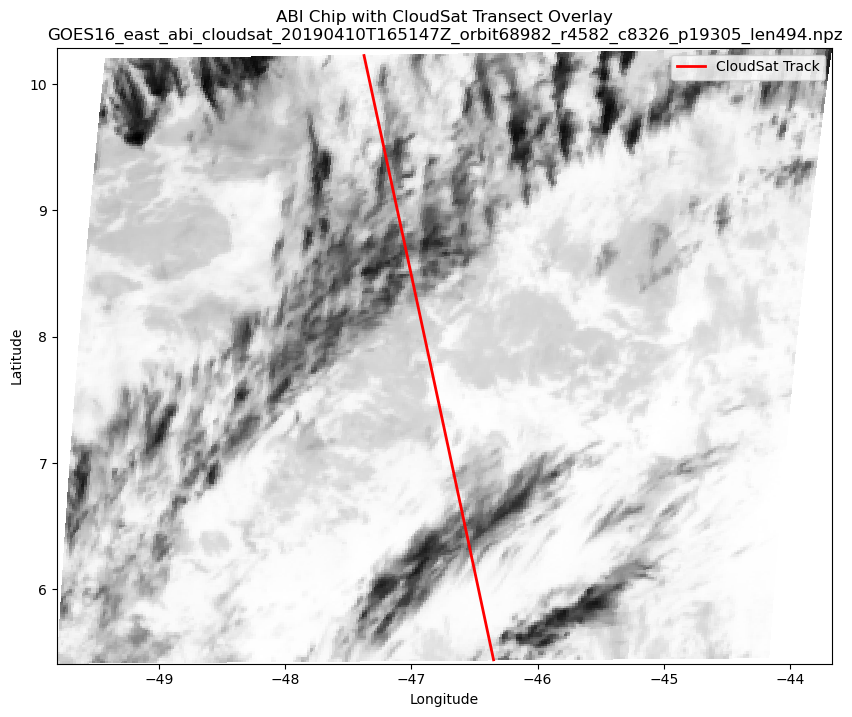

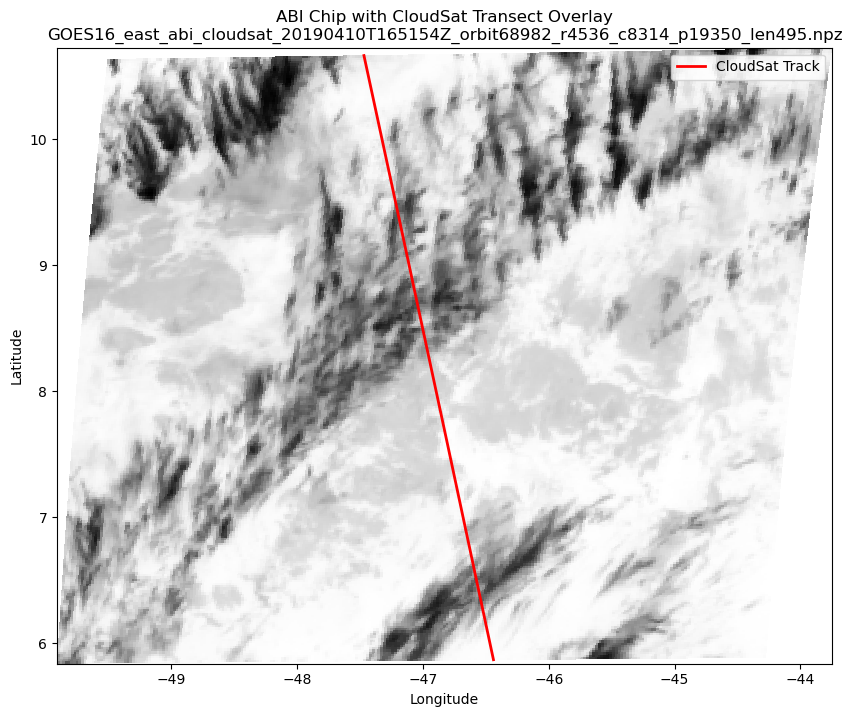

In [17]:
half = 256

for file in files:
    archive = open_npz_file(file)

    chip = archive['ABI/chip']

    cloudsat_latitude = archive['CloudSat/latitude'] 
    cloudsat_longitude = archive['CloudSat/longitude'] 

    fileName = file.split('/')[-1]
    # r c p is row column is profile index


    fileNameSplit = fileName.split('_')

    row =re.sub(r'[^0-9]', '', fileNameSplit[-4]) 
    col = re.sub(r'[^0-9]', '', fileNameSplit[-3])
    length = re.sub(r'[^0-9]', '', fileNameSplit[-1])
    eastOrWest = fileNameSplit[1]


    y_center = int(row)
    x_center = int(col)

    lat_chip = 'placeholder'
    lon_chip = 'placeholder'

    if eastOrWest == 'east':
        lat_chip = EAST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
        lon_chip = EAST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    else:
        lat_chip = WEST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
        lon_chip = WEST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]

    abi_image = chip[2, :, :, 12]
    visualize_chip(lon_chip, lat_chip, abi_image, cloudsat_latitude, cloudsat_longitude, fileName)    

   
    
